# Дополнительное задание 10  

# Задание 1

Необходимо визуализировать правило прогнозирования класса при двух порогах: 0.5 и 0.35.

Порог 0.5 является стандартным для бинарной классификации: если вероятность положительного класса больше или равна 0.5, объект относится к классу 1, иначе — к классу 0.

Порог 0.35 использовался в аудиторной лабораторной работе, поэтому дополнительно проверим, как изменение порога влияет на качество классификации.

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Создание модельного набора данных

Сформируем набор данных для бинарной классификации с двумя признаками.  
Два признака позволяют визуализировать разделяющую границу модели на плоскости.

In [39]:
X, y = make_classification(
    n_samples=230,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1,
    random_state=48
)

X = pd.DataFrame(X, columns=["Первый признак", "Второй признак"])
y = pd.Series(y, name="Класс")

X.head()

,Первый признак,Второй признак
0,-1.360912,1.677924
1,0.322488,1.930368
2,-0.869739,0.346786
3,-0.093353,2.741414
4,0.929939,0.544441


## Разбиение на обучающую и тестовую выборки

Выполним разбиение на обучающую и тестовую выборки.  
Используем `random_state = 48`, как в аудиторной лабораторной работе.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=48,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (184, 2)
Размер тестовой выборки: (46, 2)


## Обучение модели логистической регрессии

Обучим модель логистической регрессии с L2-регуляризацией.  
В аудиторной работе коэффициент регуляризации был задан через `C = 8`.

In [41]:
model = LogisticRegression(
    penalty="l2",
    C=8,
    random_state=48
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,48
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Уравнение разделяющей границы

Логистическая регрессия вычисляет вероятность положительного класса по формуле:

$$
p = \frac{1}{1 + e^{-z}}
$$

где

$$
z = w_0 + w_1x_1 + w_2x_2
$$

Для заданного порога \(t\) граница получается из условия:

$$
p = t
$$

Отсюда:

$$
z = \ln \frac{t}{1-t}
$$

Значит, уравнение разделяющей прямой:

$$
w_0 + w_1x_1 + w_2x_2 = \ln \frac{t}{1-t}
$$

Относительно второго признака:

$$
x_2 = \frac{\ln \frac{t}{1-t} - w_0 - w_1x_1}{w_2}
$$

In [42]:
def plot_decision_boundary(X_data, y_data, model, threshold, title):
    w0 = model.intercept_[0]
    w1, w2 = model.coef_[0]

    x_values = np.linspace(
        X_data["Первый признак"].min() - 1,
        X_data["Первый признак"].max() + 1,
        200
    )

    logit_threshold = np.log(threshold / (1 - threshold))
    y_values = (logit_threshold - w0 - w1 * x_values) / w2

    proba = model.predict_proba(X_data)[:, 1]
    y_pred_threshold = (proba >= threshold).astype(int)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X_data["Первый признак"],
        X_data["Второй признак"],
        c=y_pred_threshold,
        edgecolor="k"
    )
    plt.plot(x_values, y_values, linewidth=2)

    plt.xlabel("Первый признак")
    plt.ylabel("Второй признак")
    plt.title(title)
    plt.grid(True)
    plt.show()

## Визуализация правила прогнозирования при пороге 0.5

Построим разделяющую границу отдельно для обучающей и тестовой выборок.

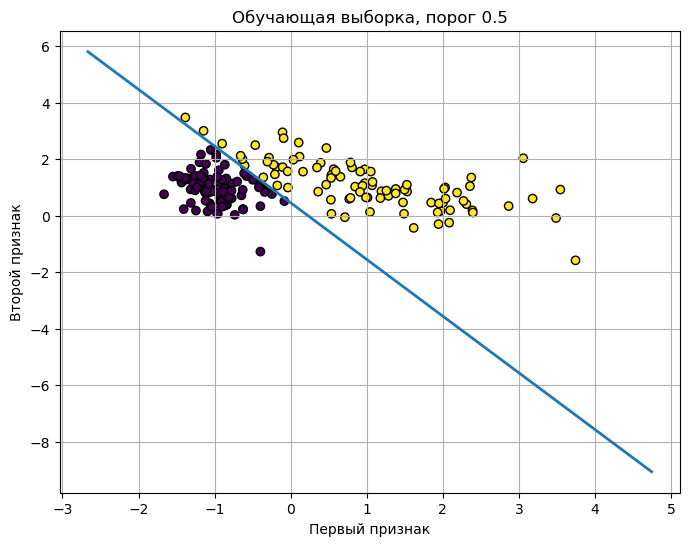

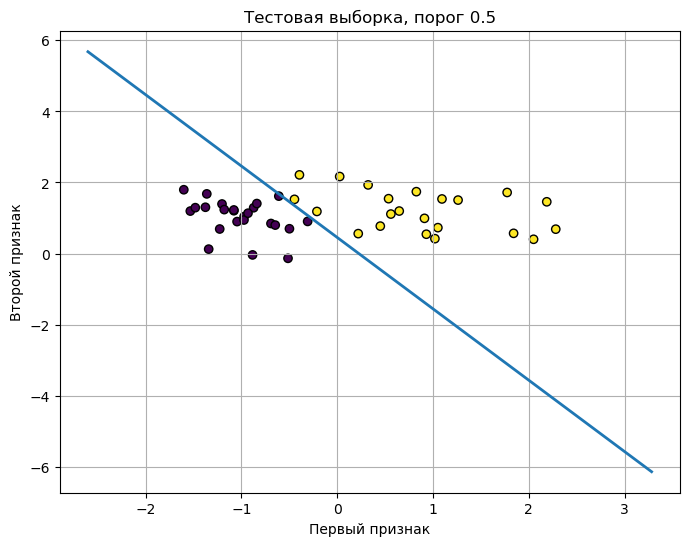

In [43]:
plot_decision_boundary(
    X_train,
    y_train,
    model,
    threshold=0.5,
    title="Обучающая выборка, порог 0.5"
)

plot_decision_boundary(
    X_test,
    y_test,
    model,
    threshold=0.5,
    title="Тестовая выборка, порог 0.5"
)

## Визуализация правила прогнозирования при пороге 0.35

Теперь изменим порог классификации на 0.35.  
При таком пороге модель чаще относит объекты к положительному классу, потому что для класса 1 требуется меньшая вероятность.

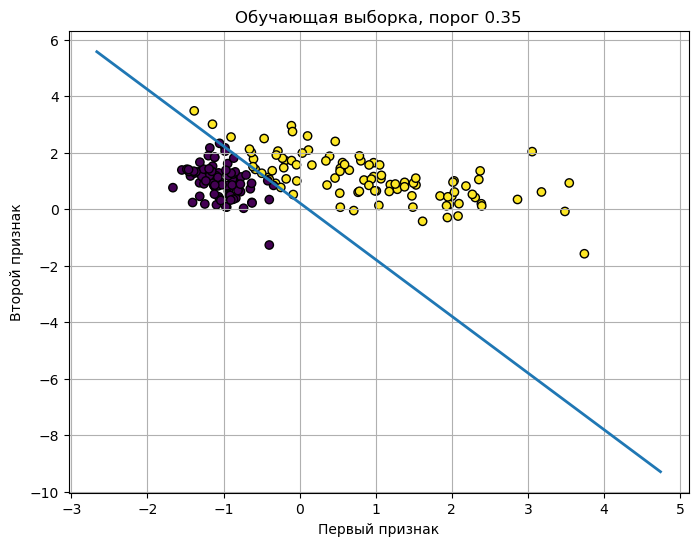

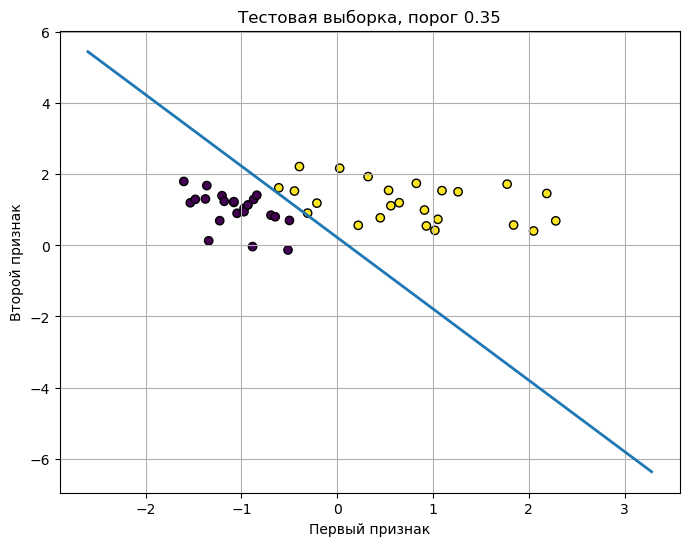

In [44]:
plot_decision_boundary(
    X_train,
    y_train,
    model,
    threshold=0.35,
    title="Обучающая выборка, порог 0.35"
)

plot_decision_boundary(
    X_test,
    y_test,
    model,
    threshold=0.35,
    title="Тестовая выборка, порог 0.35"
)

## Оценка качества классификации при пороге 0.35

Оценим качество классификации с помощью метрик accuracy, precision, recall и F1-score.

In [45]:
def get_metrics(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)

    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    })

y_train_proba = model.predict_proba(X_train)[:, 1]
y_test_proba = model.predict_proba(X_test)[:, 1]

metrics_05 = pd.DataFrame({
    "train": get_metrics(y_train, y_train_proba, 0.5),
    "test": get_metrics(y_test, y_test_proba, 0.5)
})

metrics_035 = pd.DataFrame({
    "train": get_metrics(y_train, y_train_proba, 0.35),
    "test": get_metrics(y_test, y_test_proba, 0.35)
})

print("Метрики при пороге 0.5")
display(metrics_05)

print("Метрики при пороге 0.35")
display(metrics_035)

Метрики при пороге 0.5


,train,test
accuracy,0.940217,0.934783
precision,0.955056,0.954545
recall,0.923913,0.913043
f1,0.939227,0.933333


Метрики при пороге 0.35


,train,test
accuracy,0.940217,0.934783
precision,0.917526,0.916667
recall,0.967391,0.956522
f1,0.941799,0.936170


## Вывод по заданию 1

При изменении порога классификации меняется не сама модель, а только правило перевода вероятности в метку класса.

При пороге 0.5 модель относит объект к классу 1 только тогда, когда вероятность положительного класса не меньше 50%.  
При пороге 0.35 модель становится более «мягкой» к положительному классу: больше объектов получает метку 1.

Из-за этого обычно возрастает recall, так как модель находит больше объектов положительного класса. При этом precision может снизиться, потому что среди объектов, отнесённых к классу 1, может стать больше ошибок.

Разделяющая граница остаётся линейной, потому что логистическая регрессия применяет нелинейную сигмоидную функцию к линейной комбинации признаков. Граница решения получается из условия фиксированного значения вероятности, а это условие сводится к линейному уравнению относительно признаков.

Порог 0.5 используется по умолчанию, потому что он естественно делит вероятности на две части. Однако он не всегда оптимален. Порог имеет смысл менять, когда классы несбалансированы или когда ошибки разных типов имеют разную цену.

# Задание 2

В задании используется набор данных клиентов немецких банков.  
Цель — построить модель логистической регрессии для задачи кредитного скоринга.

Целевой признак — `Класс`:

- `0` — в кредите отказано;
- `1` — кредит выдан.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

## 2.1. Импорт данных

Импортируем данные из CSV-файла, выведем первые записи и размерность набора данных.

In [48]:
df = pd.read_csv("Вариант 2_4.csv")

display(df.head())
print("Размерность набора данных:", df.shape)

,Возраст,Пол,Квалификация,Стаж,Семейное положение,Иждивенцы,Срок проживания,Иностранное гражданство,Телефон,Банковский счет,...,Плата за жилье,Кредитный рейтинг,Число кредитов,Другие кредиты,Сумма,Срок,Процентная ставка платежа,Поручители,Цель,Класс
0,22,0,2,1,замужем/живет раздельно/разведена,1,2,1,1,1,...,собственность,2,1,нет,1670,9,4,нет,радио/телевидение,0
1,24,0,2,2,замужем/живет раздельно/разведена,1,2,1,0,1,...,собственность,2,1,банк,2150,30,4,поручитель,автомобиль (новый),0
2,22,1,2,1,никогда не состоял(а),1,1,1,0,1,...,собственность,2,1,магазин,1331,12,2,нет,радио/телевидение,0
3,33,1,3,0,никогда не состоял(а),1,2,1,1,0,...,аренда,2,1,банк,4844,48,3,нет,бизнес,0
4,28,0,1,2,замужем/живет раздельно/разведена,1,2,1,0,2,...,собственность,2,1,нет,745,9,3,нет,радио/телевидение,0


Размерность набора данных: (600, 22)


## 2.2. Первичное знакомство с данными

По описанию признаков можно выделить следующие группы:

**Количественные признаки:**

- `Возраст`;
- `Иждивенцы`;
- `Число кредитов`;
- `Сумма`;
- `Срок`.

**Категориальные порядковые признаки:**

- `Квалификация`;
- `Стаж`;
- `Срок проживания`;
- `Банковский счет`;
- `Сберегательный счет`;
- `Кредитный рейтинг`;
- `Процентная ставка платежа`.

**Бинарные признаки:**

- `Пол`;
- `Иностранное гражданство`;
- `Телефон`.

**Номинальные категориальные признаки:**

- `Семейное положение`;
- `Собственность`;
- `Плата за жилье`;
- `Другие кредиты`;
- `Поручители`;
- `Цель`.

Целевой признак — `Класс`.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 600 entries, 0 to 599
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Возраст                    600 non-null    int64 
 1   Пол                        600 non-null    int64 
 2   Квалификация               600 non-null    int64 
 3   Стаж                       600 non-null    int64 
 4   Семейное положение         600 non-null    object
 5   Иждивенцы                  600 non-null    int64 
 6   Срок проживания            600 non-null    int64 
 7   Иностранное гражданство    600 non-null    int64 
 8   Телефон                    600 non-null    int64 
 9   Банковский счет            600 non-null    int64 
 10  Сберегательный счет        600 non-null    int64 
 11  Собственность              600 non-null    object
 12  Плата за жилье             600 non-null    object
 13  Кредитный рейтинг          600 non-null    int64 
 14  Число кредитов 

Проверим наличие пропущенных значений.

In [51]:
missing_values = df.isna().sum()
missing_values

Возраст                      0
Пол                          0
Квалификация                 0
Стаж                         0
Семейное положение           0
Иждивенцы                    0
Срок проживания              0
Иностранное гражданство      0
Телефон                      0
Банковский счет              0
Сберегательный счет          0
Собственность                0
Плата за жилье               0
Кредитный рейтинг            0
Число кредитов               0
Другие кредиты               0
Сумма                        0
Срок                         0
Процентная ставка платежа    0
Поручители                   0
Цель                         0
Класс                        0
dtype: int64

Проверим количество классов и число объектов в каждом классе.

In [52]:
class_counts = df["Класс"].value_counts()
class_percent = df["Класс"].value_counts(normalize=True) * 100

class_balance = pd.DataFrame({
    "Количество": class_counts,
    "Доля, %": class_percent.round(2)
})

class_balance

,Количество,"Доля, %"
Класс,,
0,300,50.0
1,300,50.0


## Комментарий по первичному анализу

В наборе данных присутствуют числовые и категориальные признаки.  
Часть категориальных признаков уже закодирована числами, например `Пол`, `Стаж`, `Квалификация`, `Кредитный рейтинг`. При этом числовой тип столбца не всегда означает, что признак является количественным: некоторые числовые столбцы являются порядковыми категориями.

Пропущенные значения отсутствуют, поэтому дополнительная обработка пропусков не требуется.

Классы в исходном наборе данных сбалансированы: объектов класса 0 и класса 1 одинаковое количество. Это удобно для обучения модели, так как классификатор не будет изначально смещён в сторону более частого класса.

## 2.3. Разбиение данных на обучающую и тестовую выборки

Разделим данные на признаки и целевой столбец.  
Разбиение выполним в соотношении 70/30.  
Используем `random_state = 48`, как в аудиторной лабораторной работе.

In [53]:
X = df.drop(columns=["Класс"])
y = df["Класс"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=48,
    stratify=y
)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

Размер обучающей выборки: (420, 21)
Размер тестовой выборки: (180, 21)


## 2.4. Проверка сбалансированности классов в обучающей и тестовой выборках

In [54]:
train_balance = y_train.value_counts(normalize=True) * 100
test_balance = y_test.value_counts(normalize=True) * 100

balance_table = pd.DataFrame({
    "Обучающая выборка, %": train_balance.round(2),
    "Тестовая выборка, %": test_balance.round(2)
})

balance_table

,"Обучающая выборка, %","Тестовая выборка, %"
Класс,,
0,50.0,50.0
1,50.0,50.0


## Комментарий

После разбиения со стратификацией соотношение классов в обучающей и тестовой выборках сохраняется.  
Это важно, потому что качество модели будет оцениваться на тестовой выборке с тем же балансом классов, что и в исходных данных.

## 2.5 Масштабирование и кодирование признаков

Для количественных и порядковых числовых признаков применим стандартизацию `StandardScaler`.  
Логистическая регрессия чувствительна к масштабу признаков, поэтому признаки с большими значениями, например `Сумма`, могут сильнее влиять на модель без масштабирования.

Бинарные признаки оставим без изменений.

Номинальные категориальные признаки закодируем с помощью `OneHotEncoder`, потому что между их значениями нет естественного порядка.

In [56]:
quantitative_features = [
    "Возраст",
    "Иждивенцы",
    "Число кредитов",
    "Сумма",
    "Срок"
]

ordinal_features = [
    "Квалификация",
    "Стаж",
    "Срок проживания",
    "Банковский счет",
    "Сберегательный счет",
    "Кредитный рейтинг",
    "Процентная ставка платежа"
]

binary_features = [
    "Пол",
    "Иностранное гражданство",
    "Телефон"
]

nominal_features = [
    "Семейное положение",
    "Собственность",
    "Плата за жилье",
    "Другие кредиты",
    "Поручители",
    "Цель"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), quantitative_features + ordinal_features),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_features)
    ]
)

## 2.6. Создание и обучение модели логистической регрессии

Создадим модель логистической регрессии с параметрами по умолчанию.  
Для корректной сходимости увеличим только `max_iter`, так как после кодирования количество признаков увеличивается.

In [57]:
log_reg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=48))
    ]
)

log_reg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('bin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 2.7. Оценка качества классификатора

Оценим качество модели на обучающей и тестовой выборках с помощью метрик:

- accuracy;
- precision;
- recall;
- F1-score.

In [58]:
def classification_metrics(model, X_data, y_true):
    y_pred = model.predict(X_data)

    return pd.Series({
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred)
    })

metrics_table = pd.DataFrame({
    "Обучающая выборка": classification_metrics(log_reg_model, X_train, y_train),
    "Тестовая выборка": classification_metrics(log_reg_model, X_test, y_test)
})

metrics_table

,Обучающая выборка,Тестовая выборка
accuracy,0.745238,0.655556
precision,0.744076,0.645833
recall,0.747619,0.688889
f1,0.745843,0.666667


## Комментарий по метрикам

На обучающей выборке качество обычно выше, чем на тестовой, потому что модель подбирала коэффициенты именно по обучающим данным.

Если качество на тестовой выборке заметно ниже, это может говорить о частичном переобучении или о том, что зависимость между признаками и целевым классом не является полностью линейной.

В данной задаче важно смотреть не только на accuracy, но и на precision, recall и F1-score, так как в кредитном скоринге ошибки разных типов имеют разную цену.

## 2.8. ROC-кривые и AUC-ROC

Построим ROC-кривые для обучающей и тестовой выборок.  
AUC-ROC показывает, насколько хорошо модель разделяет два класса по вероятностям.

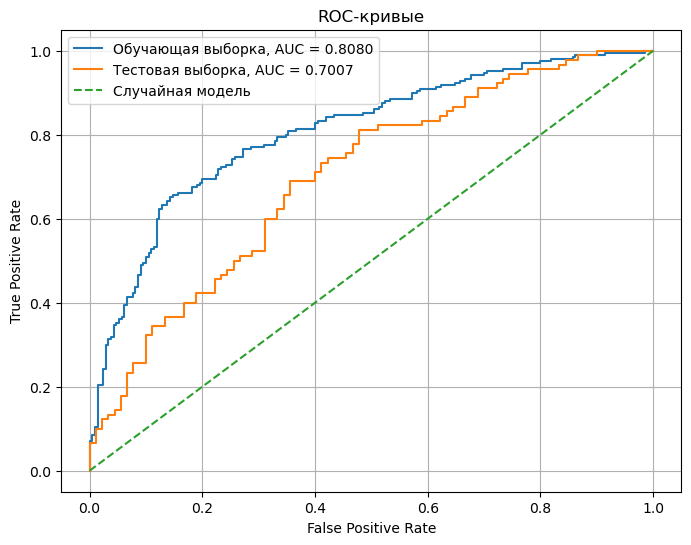

AUC-ROC на обучающей выборке: 0.808
AUC-ROC на тестовой выборке: 0.7007


In [59]:
y_train_proba = log_reg_model.predict_proba(X_train)[:, 1]
y_test_proba = log_reg_model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_proba)

auc_train = roc_auc_score(y_train, y_train_proba)
auc_test = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train, tpr_train, label=f"Обучающая выборка, AUC = {auc_train:.4f}")
plt.plot(fpr_test, tpr_test, label=f"Тестовая выборка, AUC = {auc_test:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Случайная модель")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые")
plt.legend()
plt.grid(True)
plt.show()

print("AUC-ROC на обучающей выборке:", round(auc_train, 4))
print("AUC-ROC на тестовой выборке:", round(auc_test, 4))

## 2.9. Вывод по ROC-AUC

ROC-кривая показывает способность модели различать два класса при разных порогах классификации.

Если AUC-ROC заметно больше 0.5, модель работает лучше случайного угадывания.  
Если AUC-ROC близко к 1, модель хорошо разделяет классы.  
Если AUC-ROC на обучающей выборке значительно выше, чем на тестовой, это может говорить о переобучении.

В данной задаче модель имеет приемлемую, но не идеальную предсказательную способность. Это ожидаемо, так как логистическая регрессия строит линейное правило, а реальные кредитные данные могут содержать более сложные зависимости.

## 2.10. Вывод весов модели

Выведем веса модели и отсортируем их по убыванию.  
Положительный вес увеличивает вероятность класса 1, отрицательный вес уменьшает вероятность класса 1.

In [60]:
feature_names_num = quantitative_features + ordinal_features
feature_names_bin = binary_features

ohe = log_reg_model.named_steps["preprocessor"].named_transformers_["cat"]
feature_names_cat = ohe.get_feature_names_out(nominal_features)

all_feature_names = list(feature_names_num) + list(feature_names_bin) + list(feature_names_cat)

weights = log_reg_model.named_steps["model"].coef_[0]

weights_table = pd.DataFrame({
    "Признак": all_feature_names,
    "Вес": weights
})

weights_table = weights_table.sort_values(by="Вес", ascending=False)

display(weights_table)

,Признак,Вес
32,Цель_автомобиль (б/у),0.988923
18,Семейное положение_никогда не состоял(а),0.708049
35,Цель_бытовая техника,0.584069
20,Собственность_недвижимость,0.457892
14,Телефон,0.453451
30,Поручители_поручитель,0.448843
28,Другие кредиты_нет,0.409535
25,Плата за жилье_собственность,0.390386
36,Цель_другое,0.353980
15,Семейное положение_женат/овдовел,0.350799


## 2.11. Интерпретация весов модели

Положительные веса показывают признаки, которые увеличивают вероятность выдачи кредита.  
Отрицательные веса показывают признаки, которые уменьшают вероятность выдачи кредита.

Важно учитывать, что веса интерпретируются после масштабирования и кодирования признаков. Поэтому сравнивать веса можно только внутри подготовленного пространства признаков.

Наиболее положительные веса можно интерпретировать как факторы, связанные с более высокой вероятностью одобрения кредита.  
Наиболее отрицательные веса можно интерпретировать как факторы, связанные с более высокой вероятностью отказа.

# Задание 3

В третьем задании необходимо попробовать улучшить качество логистической регрессии.

Возможные направления улучшения:

1. подобрать параметр регуляризации `C`;
2. проверить использование `class_weight`;
3. выбрать лучшую модель по F1-score;
4. сравнить качество базовой и улучшенной модели.

Так как классы в данных сбалансированы, сильного эффекта от `class_weight="balanced"` может не быть. Однако этот параметр всё равно проверим в рамках эксперимента.

In [61]:
from sklearn.model_selection import GridSearchCV

## Подбор гиперпараметров

Подберём параметр `C`, который управляет силой регуляризации.

Малое значение `C` означает более сильную регуляризацию.  
Большое значение `C` означает более слабую регуляризацию.

In [63]:
improved_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=3000, random_state=48))
    ]
)

param_grid = {
    "model__C": [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10],
    "model__class_weight": [None, "balanced"],
    "model__solver": ["liblinear"]
}

grid_search = GridSearchCV(
    estimator=improved_model,
    param_grid=param_grid,
    scoring="f1",
    cv=5
)

grid_search.fit(X_train, y_train)

print("Лучшие параметры:")
print(grid_search.best_params_)

print("Лучший средний F1-score на кросс-валидации:")
print(round(grid_search.best_score_, 4))

Лучшие параметры:
{'model__C': 0.01, 'model__class_weight': None, 'model__solver': 'liblinear'}
Лучший средний F1-score на кросс-валидации:
0.6875


## Оценка улучшенной модели

Проверим качество лучшей найденной модели на обучающей и тестовой выборках.

In [64]:
best_model = grid_search.best_estimator_

improved_metrics_table = pd.DataFrame({
    "Обучающая выборка": classification_metrics(best_model, X_train, y_train),
    "Тестовая выборка": classification_metrics(best_model, X_test, y_test)
})

improved_metrics_table

,Обучающая выборка,Тестовая выборка
accuracy,0.707143,0.666667
precision,0.698630,0.653061
recall,0.728571,0.711111
f1,0.713287,0.680851


## Сравнение базовой и улучшенной модели

In [65]:
comparison_table = pd.concat(
    {
        "Базовая модель": metrics_table,
        "Улучшенная модель": improved_metrics_table
    },
    axis=1
)

comparison_table

Базовая модель                  Улучшенная модель  \
          Обучающая выборка Тестовая выборка Обучающая выборка   
accuracy           0.745238         0.655556          0.707143   
precision          0.744076         0.645833          0.698630   
recall             0.747619         0.688889          0.728571   
f1                 0.745843         0.666667          0.713287   

                            
          Тестовая выборка  
accuracy          0.666667  
precision         0.653061  
recall            0.711111  
f1                0.680851

## ROC-AUC для улучшенной модели

In [66]:
best_train_proba = best_model.predict_proba(X_train)[:, 1]
best_test_proba = best_model.predict_proba(X_test)[:, 1]

best_auc_train = roc_auc_score(y_train, best_train_proba)
best_auc_test = roc_auc_score(y_test, best_test_proba)

print("AUC-ROC улучшенной модели на обучающей выборке:", round(best_auc_train, 4))
print("AUC-ROC улучшенной модели на тестовой выборке:", round(best_auc_test, 4))

AUC-ROC улучшенной модели на обучающей выборке: 0.7649
AUC-ROC улучшенной модели на тестовой выборке: 0.6981


## Итоговый вывод по заданию 3

В рамках улучшения модели был выполнен подбор гиперпараметров логистической регрессии.  
Основное внимание было уделено параметру регуляризации `C`, так как он влияет на сложность модели и помогает бороться с переобучением.

Также был проверен параметр `class_weight`, хотя исходные классы являются сбалансированными. Поэтому значительного преимущества от балансировки весов классов ожидать не стоит.

Если улучшенная модель показывает более высокий F1-score на тестовой выборке, её можно считать более предпочтительной.  
Если улучшение небольшое, это означает, что базовая логистическая регрессия уже достаточно близка к оптимальному качеству для данного набора признаков.

Главное ограничение логистической регрессии состоит в том, что она строит линейную зависимость между признаками и логитом вероятности. Поэтому при сложных нелинейных зависимостях качество может быть ограничено даже после подбора гиперпараметров.